# Advanced Python Time-Series Analysis of Apple Inc. Stock Market Data

## Project Objective

This project analyzes Apple Inc. historical stock market data using Python. The goal is to apply advanced Pandas techniques, perform time-series analysis, create useful features, visualize stock trends, and generate meaningful insights from the data.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
!pip install yfinance

In [ ]:
import yfinance as yf
import pandas as pd

aapl = yf.download(
    "AAPL",
    period="5y",
    interval="1d",
    auto_adjust=False
)

if isinstance(aapl.columns, pd.MultiIndex):
    aapl.columns = aapl.columns.get_level_values(0)

aapl = aapl.reset_index()

aapl.to_csv("AAPL_5_year_historical_data.csv", index=False)

aapl.head()

[*********************100%***********************]  1 of 1 completed


Price,Date,Adj Close,Close,High,Low,Open,Volume
0,2021-07-12,140.851654,144.500000,146.320007,144.000000,146.210007,76299700
1,2021-07-13,141.962906,145.639999,147.460007,143.630005,144.029999,100827100
2,2021-07-14,145.384216,149.149994,149.570007,147.679993,148.100006,127050800
3,2021-07-15,144.731171,148.479996,150.000000,147.089996,149.240005,106820300
4,2021-07-16,142.693939,146.389999,149.759995,145.880005,148.460007,93251400


The Apple Inc. historical stock market data was obtained from Yahoo Finance using the yfinance Python library. The dataset covers a 5-year period and contains daily stock price information including Open, High, Low, Close, Adjusted Close, and Volume.

In [ ]:
aapl.head()

Price,Date,Adj Close,Close,High,Low,Open,Volume
0,2021-07-12,140.851654,144.500000,146.320007,144.000000,146.210007,76299700
1,2021-07-13,141.962906,145.639999,147.460007,143.630005,144.029999,100827100
2,2021-07-14,145.384216,149.149994,149.570007,147.679993,148.100006,127050800
3,2021-07-15,144.731171,148.479996,150.000000,147.089996,149.240005,106820300
4,2021-07-16,142.693939,146.389999,149.759995,145.880005,148.460007,93251400


In [ ]:
aapl.shape

(1255, 7)

In [ ]:
aapl.columns

Index(['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')

In [ ]:
aapl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1255 entries, 0 to 1254
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       1255 non-null   datetime64[ns]
 1   Adj Close  1255 non-null   float64       
 2   Close      1255 non-null   float64       
 3   High       1255 non-null   float64       
 4   Low        1255 non-null   float64       
 5   Open       1255 non-null   float64       
 6   Volume     1255 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 68.8 KB


## Data Cleaning and Preprocessing

In this section, I checked the dataset for missing values, duplicate records, incorrect data types, and date ordering. This ensures the dataset is clean and ready for time-series analysis.

In [ ]:
aapl.columns.name = None

In [ ]:
aapl.isnull().sum()

,0
Date,0
Adj Close,0
Close,0
High,0
Low,0
Open,0
Volume,0


In [ ]:
aapl.duplicated().sum()

np.int64(0)

In [ ]:
aapl = aapl.reset_index(drop=True)

**Data Transformation and Feature Engineering**

In this section, new features are created from the existing stock price data to support deeper analysis. These features help measure daily stock movement, percentage changes, monthly patterns, moving averages, and volatility.




In [ ]:
aapl['Year'] = aapl['Date'].dt.year
aapl['Month'] = aapl['Date'].dt.month
aapl['Month_Name'] = aapl['Date'].dt.month_name()

In [ ]:
aapl['Daily_Price_Change'] = aapl['Close'] - aapl['Open']

In [ ]:
aapl['Daily_Percentage_Change'] = aapl['Close'].pct_change() * 100

In [ ]:
aapl['Daily_Percentage_Change'] = aapl['Daily_Percentage_Change'].fillna(0)

### Moving Averages

Creating moving averages in order to smooth daily price fluctuations and reveal clearer short-term and medium-term stock price trends. A 7-day moving average will be used to observe short-term movement, while a 30-day moving average will be used to observe broader price direction.

In [ ]:
aapl['MA_7'] = aapl['Close'].rolling(window=7).mean()
aapl['MA_30'] = aapl['Close'].rolling(window=30).mean()

### Trading Range and Volatility

Trading range was created to measure the difference between the highest and lowest price recorded in a trading day. A 30-day rolling volatility measure was also created using daily percentage change to observe periods of higher or lower price fluctuation.

In [ ]:
aapl["Trading_Range"] = aapl["High"] - aapl["Low"]

In [ ]:
aapl["Volatility_30"] = aapl["Daily_Percentage_Change"].rolling(window=30).std()

In [ ]:
aapl[['Date', 'Open', 'Close', 'Year', 'Month', 'Month_Name', 'High', 'Low', 'Trading_Range', 'Daily_Price_Change', 'Daily_Percentage_Change', 'Volatility_30', 'MA_7', 'MA_30',]].head(35).round(2)

,Date,Open,Close,Year,Month,Month_Name,High,Low,Trading_Range,Daily_Price_Change,Daily_Percentage_Change,Volatility_30,MA_7,MA_30
0,2021-07-12,146.21,144.50,2021,7,July,146.32,144.00,2.32,-1.71,0.00,NaN,NaN,NaN
1,2021-07-13,144.03,145.64,2021,7,July,147.46,143.63,3.83,1.61,0.79,NaN,NaN,NaN
2,2021-07-14,148.10,149.15,2021,7,July,149.57,147.68,1.89,1.05,2.41,NaN,NaN,NaN
3,2021-07-15,149.24,148.48,2021,7,July,150.00,147.09,2.91,-0.76,-0.45,NaN,NaN,NaN
4,2021-07-16,148.46,146.39,2021,7,July,149.76,145.88,3.88,-2.07,-1.41,NaN,NaN,NaN
5,2021-07-19,143.75,142.45,2021,7,July,144.07,141.67,2.40,-1.30,-2.69,NaN,NaN,NaN
6,2021-07-20,143.46,146.15,2021,7,July,147.10,142.96,4.14,2.69,2.60,NaN,146.11,NaN
7,2021-07-21,145.53,145.40,2021,7,July,146.13,144.63,1.50,-0.13,-0.51,NaN,146.24,NaN
8,2021-07-22,145.94,146.80,2021,7,July,148.20,145.81,2.39,0.86,0.96,NaN,146.40,NaN
9,2021-07-23,147.55,148.56,2021,7,July,148.72,146.92,1.80,1.01,1.20,NaN,146.32,NaN


## Monthly Time-Series Analysis

In this section, the daily stock data will be aggregated into monthly values to better understand Apple’s stock performance over time. Monthly analysis helps reduce daily noise and reveal broader performance trends.

In [ ]:
monthly_summary = aapl.groupby(['Year', 'Month', 'Month_Name']).agg(
    Average_Close=('Close', 'mean'),
    Highest_Close=('Close', 'max'),
    Lowest_Close=('Close', 'min'),
    Total_Volume=('Volume', 'sum'),
    Average_Daily_Change=('Daily_Price_Change', 'mean'),
    Average_Volatility=('Volatility_30', 'mean')
).reset_index()

monthly_summary.head()

,Year,Month,Month_Name,Average_Close,Highest_Close,Lowest_Close,Total_Volume,Average_Daily_Change,Average_Volatility
0,2021,7,July,146.383999,149.149994,142.449997,1369137000,0.147996,NaN
1,2021,8,August,148.177727,153.119995,145.520004,1461542800,0.326818,1.198683
2,2021,9,September,148.306190,156.690002,141.500000,1797835100,-0.695715,1.245540
3,2021,10,October,145.563809,152.570007,139.139999,1565079200,0.592380,1.303514
4,2021,11,November,154.255716,165.300003,147.869995,1691029000,0.651906,1.135307


In [ ]:
monthly_summary = monthly_summary.sort_values(['Year', 'Month']).reset_index(drop=True)

monthly_summary.head(10).round(2)

,Year,Month,Month_Name,Average_Close,Highest_Close,Lowest_Close,Total_Volume,Average_Daily_Change,Average_Volatility
0,2021,7,July,146.38,149.15,142.45,1369137000,0.15,NaN
1,2021,8,August,148.18,153.12,145.52,1461542800,0.33,1.20
2,2021,9,September,148.31,156.69,141.50,1797835100,-0.70,1.25
3,2021,10,October,145.56,152.57,139.14,1565079200,0.59,1.30
4,2021,11,November,154.26,165.30,147.87,1691029000,0.65,1.14
5,2021,12,December,173.55,180.33,161.84,2444766700,0.40,1.70
6,2022,1,January,169.86,182.01,159.22,2108446000,-0.34,1.82
7,2022,2,February,169.83,176.28,160.07,1627516300,0.19,1.91
8,2022,3,March,165.31,178.96,150.62,2180800100,0.50,1.96
9,2022,4,April,166.82,178.44,156.57,1687795600,-0.66,1.90


In [ ]:
aapl['Year_Month'] = aapl['Date'].dt.to_period('M')

In [ ]:
monthly_returns = aapl.groupby('Year_Month').agg(
    Month_End_Close=('Close', 'last')
).reset_index()

In [ ]:
monthly_returns['Monthly_Return'] = monthly_returns['Month_End_Close'].pct_change() * 100

In [ ]:
monthly_returns['Monthly_Return'] = monthly_returns['Monthly_Return'].fillna(0)

In [ ]:
monthly_returns['Year'] = monthly_returns['Year_Month'].dt.year
monthly_returns['Month'] = monthly_returns['Year_Month'].dt.month

In [ ]:
monthly_summary = monthly_summary.merge(
    monthly_returns[['Year', 'Month', 'Monthly_Return']],
    on=['Year', 'Month'],
    how='left'
)

In [ ]:
monthly_summary.head(10).round(2)

,Year,Month,Month_Name,Average_Close,Highest_Close,Lowest_Close,Total_Volume,Average_Daily_Change,Average_Volatility,Monthly_Return
0,2021,7,July,146.38,149.15,142.45,1369137000,0.15,NaN,0.00
1,2021,8,August,148.18,153.12,145.52,1461542800,0.33,1.20,4.09
2,2021,9,September,148.31,156.69,141.50,1797835100,-0.70,1.25,-6.80
3,2021,10,October,145.56,152.57,139.14,1565079200,0.59,1.30,5.87
4,2021,11,November,154.26,165.30,147.87,1691029000,0.65,1.14,10.35
5,2021,12,December,173.55,180.33,161.84,2444766700,0.40,1.70,7.42
6,2022,1,January,169.86,182.01,159.22,2108446000,-0.34,1.82,-1.57
7,2022,2,February,169.83,176.28,160.07,1627516300,0.19,1.91,-5.53
8,2022,3,March,165.31,178.96,150.62,2180800100,0.50,1.96,5.75
9,2022,4,April,166.82,178.44,156.57,1687795600,-0.66,1.90,-9.71


**Exploratory Data Analysis**



Highest Average Closing Price

In [ ]:
monthly_summary.loc[monthly_summary['Average_Close'].idxmax()]

,60
Year,2026
Month,7
Month_Name,July
Average_Close,310.180006
Highest_Close,316.220001
Lowest_Close,294.380005
Total_Volume,345154200
Average_Daily_Change,3.415719
Average_Volatility,2.088517
Monthly_Return,8.971531


Lowest average closing price

In [ ]:
monthly_summary.loc[monthly_summary['Average_Close'].idxmin()]

,18
Year,2023
Month,1
Month_Name,January
Average_Close,135.778999
Highest_Close,145.929993
Lowest_Close,125.019997
Total_Volume,1443652500
Average_Daily_Change,0.652999
Average_Volatility,2.002451
Monthly_Return,11.052106


Highest trading volume

In [ ]:
monthly_summary.loc[monthly_summary['Total_Volume'].idxmax()]

,5
Year,2021
Month,12
Month_Name,December
Average_Close,173.552727
Highest_Close,180.330002
Lowest_Close,161.839996
Total_Volume,2444766700
Average_Daily_Change,0.397273
Average_Volatility,1.697352
Monthly_Return,7.42287


Best monthly return

In [ ]:
monthly_summary.loc[monthly_summary['Monthly_Return'].idxmax()]

,12
Year,2022
Month,7
Month_Name,July
Average_Close,149.670499
Highest_Close,162.509995
Lowest_Close,138.929993
Total_Volume,1447125400
Average_Daily_Change,1.234
Average_Volatility,2.175814
Monthly_Return,18.863365


Worst monthly return

In [ ]:
monthly_summary.loc[monthly_summary['Monthly_Return'].idxmin()]

,17
Year,2022
Month,12
Month_Name,December
Average_Close,137.876666
Highest_Close,148.309998
Lowest_Close,126.040001
Total_Volume,1675731200
Average_Daily_Change,-0.859049
Average_Volatility,2.561606
Monthly_Return,-12.227255


### Initial Key Insights from Monthly Analysis

The monthly analysis showed that Apple’s stock reached its highest average closing price in July 2026, although this may represent partial-month data. The lowest average closing price occurred in January 2023, showing that this was one of the weaker periods in the 5-year dataset.

December 2021 recorded the highest trading volume, indicating a period of strong market activity. In terms of monthly returns, July 2022 had the best performance with a monthly return of about 18.86%, while December 2022 had the weakest performance with a monthly return of about -12.23%.

These findings suggest that Apple’s stock experienced both strong growth periods and periods of decline, making trend, return, and volatility analysis important for understanding its overall movement.

**DATA VISUALIZATION**

### Visualization 1. Apple Closing Price Trend


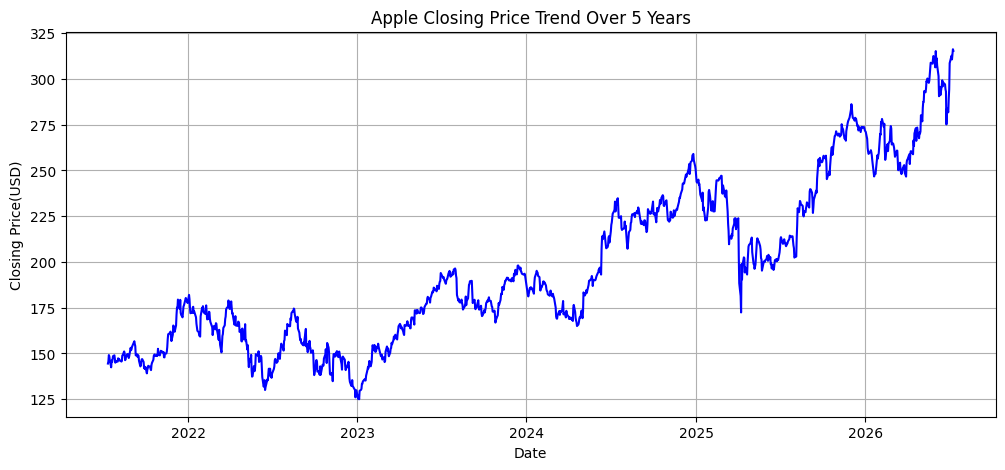

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(aapl['Date'], aapl['Close'], label='Closing Price', color='blue')
plt.title('Apple Closing Price Trend Over 5 Years')
plt.xlabel('Date')
plt.ylabel('Closing Price(USD)')
plt.grid(True)
plt.show()

**Insight:**  
Apple’s closing price showed an overall upward trend across the 5-year period. The stock experienced noticeable declines around late 2022 to early 2023 and again showed some fluctuations around 2025, but it recovered strongly and reached its highest levels in 2026. This suggests that Apple’s stock demonstrated long-term growth despite short-term price movements.

## Visualization 2: Trading Volume Trend

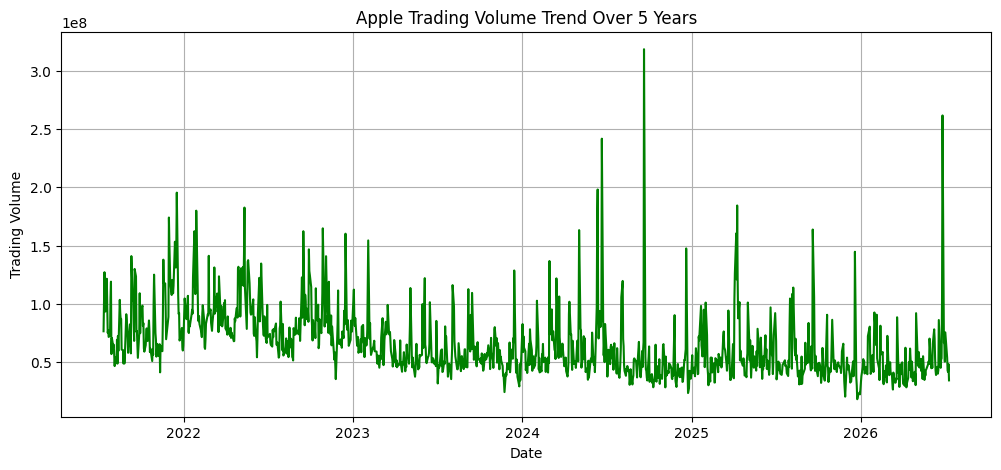

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(aapl['Date'], aapl['Volume'], label='Trading Volume', color='green')
plt.title('Apple Trading Volume Trend Over 5 Years')
plt.xlabel('Date')
plt.ylabel('Trading Volume')
plt.grid(True)
plt.show()

**Insight:**  
Apple’s trading volume showed several noticeable spikes over the 5-year period, indicating periods of increased market activity. While daily trading volume fluctuated regularly, some periods experienced much higher activity than usual. These spikes may be linked to major market events, investor reactions, earnings periods, or broader changes in market sentiment.

**Visualization 3: Moving Average Analysis**

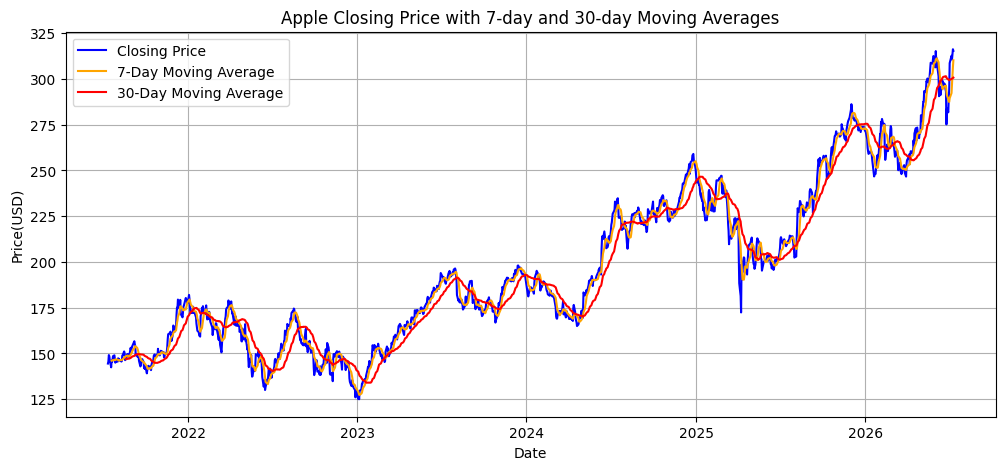

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(aapl['Date'], aapl['Close'], label='Closing Price', color='blue')
plt.plot(aapl['Date'], aapl['MA_7'], label='7-Day Moving Average', color='orange')
plt.plot(aapl['Date'], aapl['MA_30'], label='30-Day Moving Average', color='red')
plt.title('Apple Closing Price with 7-day and 30-day Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price(USD)')
plt.legend()
plt.grid(True)
plt.show()

**Insight:**  
The moving average analysis shows that Apple’s stock experienced short-term fluctuations, but the overall trend became clearer after smoothing the data. The 7-day moving average followed the closing price closely, while the 30-day moving average provided a smoother view of the broader trend. From 2023 onward, both moving averages showed a stronger upward movement, suggesting improved stock performance over time.

### Visualization 4. Monthly Returns Analysis

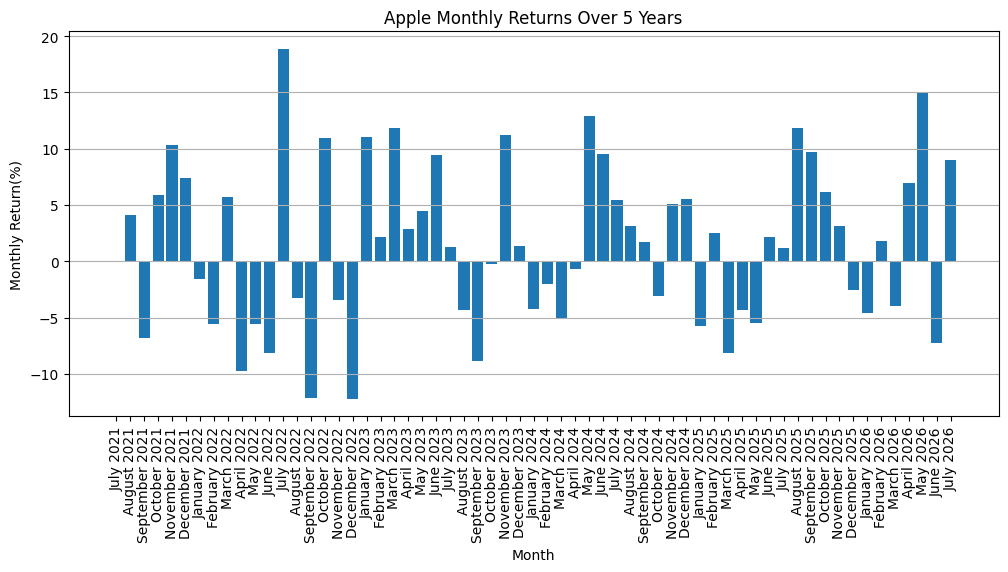

In [ ]:
plt.figure(figsize=(12, 5))
plt.bar(
    monthly_summary['Month_Name'] + ' ' + monthly_summary['Year'].astype(str),
    monthly_summary['Monthly_Return']
)
plt.title('Apple Monthly Returns Over 5 Years')
plt.xlabel('Month')
plt.ylabel('Monthly Return(%)')
plt.xticks(rotation=90)
plt.grid(axis='y')
plt.show()

**Insight:**  
The monthly returns analysis shows that Apple’s stock experienced both strong gains and losses across the 5-year period. July 2022 recorded the highest monthly return at about 18.86%, while December 2022 recorded the weakest monthly return at about -12.23%. This shows that although Apple’s stock had long-term growth, its short-term monthly performance still fluctuated significantly.

## Visualization 5: Volatility Trend

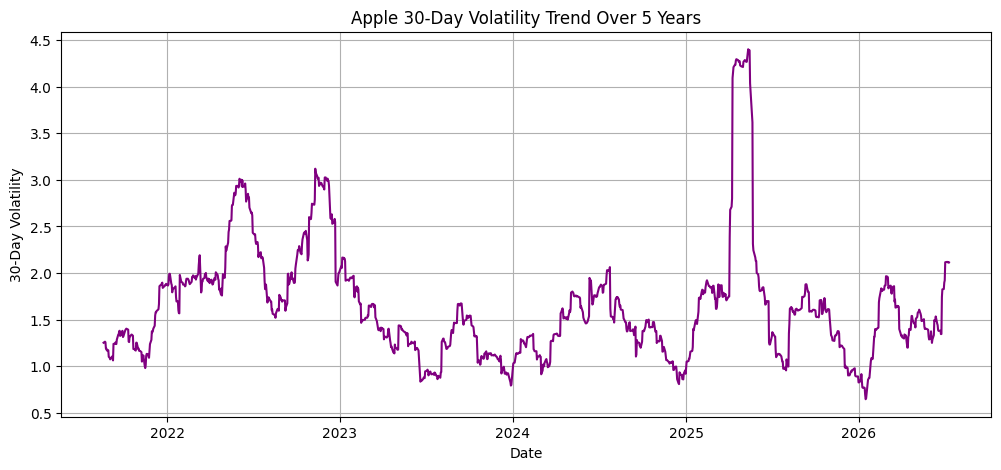

In [43]:
plt.figure(figsize=(12,5))
plt.plot(aapl['Date'], aapl['Volatility_30'], label='30-Day Volatility', color='purple')
plt.title('Apple 30-Day Volatility Trend Over 5 Years')
plt.xlabel('Date')
plt.ylabel('30-Day Volatility')
plt.grid(True)
plt.show()

**Insight:**  
The 30-day rolling volatility chart shows that Apple’s stock experienced different levels of price fluctuation across the 5-year period. Volatility was relatively moderate in some periods, but there were noticeable spikes, especially around 2025. This suggests that Apple’s stock went through periods of increased uncertainty or stronger market movement, even though the overall long-term price trend was upward.

**Final Key Findings**

## Key Findings

1. Apple’s closing price showed an overall upward trend across the 5-year period, despite short-term declines and fluctuations.

2. The lowest average closing price occurred in January 2023, while the highest average closing price occurred in July 2026. However, July 2026 may represent partial-month data.

3. December 2021 recorded the highest trading volume, showing a period of strong market activity.

4. Monthly return analysis showed that July 2022 had the strongest monthly performance, with a return of about 18.86%.

5. December 2022 had the weakest monthly return, with a decline of about -12.23%.

6. The moving average analysis showed that the 7-day moving average followed short-term price movements closely, while the 30-day moving average gave a smoother view of the broader trend.

7. The volatility analysis showed that Apple’s stock experienced periods of higher price fluctuation, especially around 2025.

## Recommendations

1. Investors and analysts should monitor both closing price trends and moving averages to better understand Apple’s stock direction over time.

2. Monthly returns should be reviewed to identify periods of strong and weak performance instead of relying only on daily price changes.

3. Volatility should be considered when evaluating risk, because Apple’s stock experienced periods of stronger price fluctuation.

4. Further analysis can include comparing Apple’s performance with other technology stocks or adding external market indicators for deeper insight.

## Conclusion

This project applied advanced Python techniques to analyze Apple Inc. historical stock market data over a 5-year period. The analysis involved data cleaning, transformation, time-series analysis, feature engineering, and visualization.

New features such as daily price change, daily percentage change, moving averages, monthly returns, trading range, and rolling volatility were created to support deeper analysis. The results showed that Apple’s stock had an overall upward trend, although it experienced periods of decline, increased volatility, and fluctuating monthly returns.

Overall, the project demonstrated how Python and Pandas can be used to transform raw stock market data into meaningful insights for financial and time-series analysis.

In [44]:
aapl.to_csv('AAPL_cleaned_featured_data.csv', index=False)
monthly_summary.to_csv('AAPL_monthly_summary.csv', index=False)
monthly_returns.to_csv('AAPL_monthly_returns.csv', index=False)